# Requirement 3 — Best-of-Both-Worlds, Multi-Campaign Primal-Dual Bidding

**Setting:** same N-campaign instance as Requirement 2 (shared budget $B_{\text{total}}$, per-round
budget $\rho$, conflict graph $G$), evaluated in **two** environments:

1. **Stochastic** — $m_{i,t} \sim \text{Beta}(k_i, 1)$ i.i.d. (the Requirement 2 environment).
2. **Highly non-stationary** — a fixed non-stochastic sequence: the Beta parameter $k_i(t)$ jumps
   abruptly every ~50–150 rounds and drifts sinusoidally, with change points staggered across
   campaigns so the best independent set rotates over time.

**Algorithm:** `PrimalDualBidderAgent` — a primal-dual method with **full feedback**
(the highest competing bid $m_{i,t}$ of *every* campaign is observed each round):

- **Primal:** one Hedge learner per campaign over the bid grid, updated with the full-feedback
  Lagrangian payoff $f_{i,k,t} - \lambda_t\, c_{i,k,t}$ (rescaled to $[0,1]$).
- **Dual:** online gradient descent on the shared multiplier
  $\lambda_{t+1} = \Pi_{[0,1/\rho]}\big(\lambda_t - \eta_d(\rho - \mathbb{E}_{x_t}[c_t])\big)$ —
  $\lambda$ performs the budget pacing automatically.
- **Conflict graph:** each round a max-weight independent set is chosen, weighting campaign $i$
  by its expected Lagrangian value under the current $\lambda_t$; campaigns with non-positive
  value are dropped (bidding 0 dominates).

**Baselines:**
- Stochastic: the Requirement 2 LP clairvoyant (true win probabilities).
- Non-stationary: **best fixed feasible strategy in hindsight** — the same LP fed with the
  *empirical* win rates of the realized sequence. This is the standard adversarial comparator;
  the stronger per-round best policy is unattainable under fast changes.

In [1]:
import sys, os

# Resolve repo root whether notebook is run from repo root or notebooks/
repo_root = os.path.abspath('.')
if not os.path.isdir(os.path.join(repo_root, 'src')):
    repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import matplotlib.pyplot as plt

from src.core.multi_campaign_env import MultiCampaignEnv
from src.core.nonstationary_env import NonStationaryMultiCampaignEnv
from src.core.conflict_graph import ConflictGraph
from src.core.primal_dual_bidder import PrimalDualBidderAgent
from src.core.cucb_bidder import CombUCBLikeBidderAgent
from src.core.clairvoyant import (
    win_probs_multi_campaign,
    clairvoyant_multi_campaign,
    best_fixed_in_hindsight,
)
from src.utils.parallel_runner import run_trials_parallel
from src.utils.regret import summarise_regret
from src.utils.plotting import new_figure, plot_regret, save_figure

n_jobs = os.cpu_count()
print(f"Using n_jobs = {n_jobs} worker processes")

Using n_jobs = 10 worker processes


## Problem Instance

Identical to Requirement 2 for comparability: five campaigns, conflict edges (0,1) and (2,3),
shared bid grid, $\rho = 0.4$.

In [2]:
# --- Problem parameters (same instance as Requirement 2) ---
N           = 5
K           = 20
T           = 15000
master_seed = 42
seq_seed    = 777      # fixes the non-stationary sequence across trials

values        = np.array([0.90, 0.80, 0.70, 0.85, 0.75])
n_competitors = np.array([3, 2, 4, 2, 3])   # stochastic env only

bid_grid = np.linspace(0.0, 1.0, K)
edges    = [(0, 1), (2, 3)]
cg       = ConflictGraph(N, edges)

rho     = 0.40
B_total = rho * T

# Trial counts: the primal-dual agent is cheap per round (no LPs), so we can
# afford more trials than the CUCB baseline (one LP per independent set per round).
n_trials_pd   = 20
n_trials_cucb = 8

print(f"T = {T},  rho = {rho},  B_total = {B_total:.0f}")
print(f"Hedge eta = {np.sqrt(np.log(K)/T):.5f}   OGD eta = {1/np.sqrt(T):.5f}")

T = 15000,  rho = 0.4,  B_total = 6000
Hedge eta = 0.01413   OGD eta = 0.00816


## Part 1 — Stochastic Environment

The primal-dual agent should be no-regret here too (any stochastic environment is a special
case of the adversarial one), though with worse constants than CUCB, which exploits the
i.i.d. structure.

In [3]:
win_probs = win_probs_multi_campaign(bid_grid, n_competitors)
_, cv_stoch, cv_stoch_cost = clairvoyant_multi_campaign(bid_grid, values, rho, win_probs, cg)
print(f"Stochastic clairvoyant: reward/round = {cv_stoch:.4f},  cost/round = {cv_stoch_cost:.4f}")

Stochastic clairvoyant: reward/round = 0.1989,  cost/round = 0.4000


In [4]:
print(f"Running {n_trials_pd} trials x {T} rounds (primal-dual, stochastic) ...")
results_pd_stoch = run_trials_parallel(
    env_cls=MultiCampaignEnv,
    env_kwargs=dict(values=values, T=T, n_competitors=n_competitors),
    agent_cls=PrimalDualBidderAgent,
    agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg),
    T=T,
    n_trials=n_trials_pd,
    master_seed=master_seed,
    clairvoyant_reward=cv_stoch,
    n_jobs=n_jobs,
)
print("Done.")

Running 20 trials x 15000 rounds (primal-dual, stochastic) ...
Done.


Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req3_regret_stochastic.png
Final regret (stochastic): 943.14 +/- 22.43
For reference, CUCB achieved ~1329 on this instance in Requirement 2.


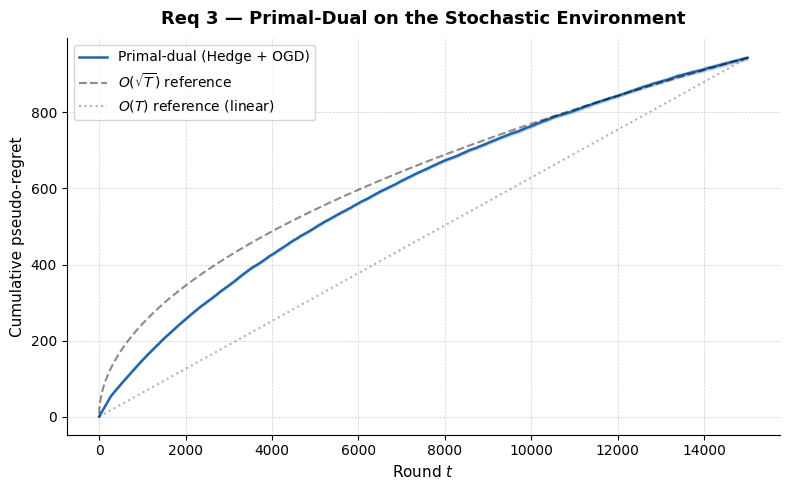

In [5]:
mean_pd_s, std_pd_s = summarise_regret(results_pd_stoch["regret_matrix"])
ts = np.arange(1, T + 1)

fig, ax = new_figure("Req 3 — Primal-Dual on the Stochastic Environment")
plot_regret(ax, mean_pd_s, std_pd_s, n_trials_pd, label="Primal-dual (Hedge + OGD)")
ax.plot(ts, mean_pd_s[-1] * np.sqrt(ts / T), 'k--', alpha=0.45, label=r'$O(\sqrt{T})$ reference')
ax.plot(ts, mean_pd_s[-1] * (ts / T), 'k:', alpha=0.3, label=r'$O(T)$ reference (linear)')
ax.set_xlabel("Round $t$")
ax.set_ylabel("Cumulative pseudo-regret")
ax.legend()
plt.tight_layout()
save_figure(fig, "report/figures/req3_regret_stochastic.png")

print(f"Final regret (stochastic): {mean_pd_s[-1]:.2f} +/- {std_pd_s[-1]:.2f}")
print(f"For reference, CUCB achieved ~1329 on this instance in Requirement 2.")

## Part 2 — Highly Non-Stationary Environment

The sequence is generated **once** from `seq_seed` and shared by every trial (the course
protocol for adversarial evaluation: the sequence is fixed, uncertainty comes only from the
algorithm's own randomization). First, visualise how fast it changes.

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req3_nonstationary_sequence.png
Abrupt jumps across all campaigns: ~609 over T=15000 rounds


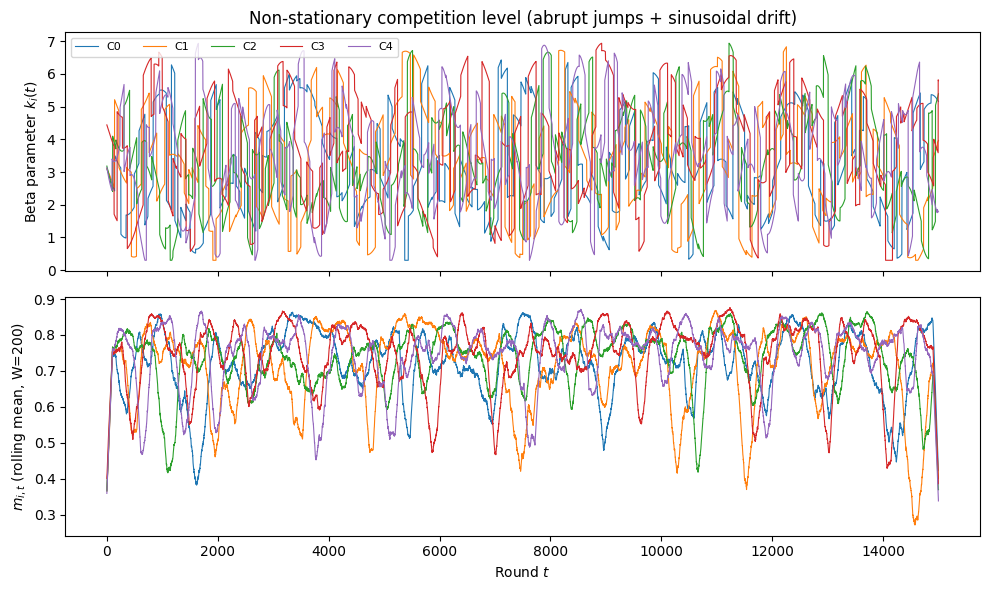

In [6]:
env_ns = NonStationaryMultiCampaignEnv(values=values, T=T, sequence_seed=seq_seed)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i in range(N):
    ax1.plot(env_ns.k_seq[:, i], lw=0.8, label=f"C{i}")
ax1.set_ylabel("Beta parameter $k_i(t)$")
ax1.set_title("Non-stationary competition level (abrupt jumps + sinusoidal drift)")
ax1.legend(ncol=N, fontsize=8)

W = 200  # rolling window for the (noisy) realized bids
kernel = np.ones(W) / W
for i in range(N):
    ax2.plot(np.convolve(env_ns.m_seq[:, i], kernel, mode='same'), lw=0.8, label=f"C{i}")
ax2.set_ylabel(f"$m_{{i,t}}$ (rolling mean, W={W})")
ax2.set_xlabel("Round $t$")
plt.tight_layout()
save_figure(fig, "report/figures/req3_nonstationary_sequence.png")

n_jumps = int((np.abs(np.diff(env_ns.k_seq, axis=0)) > 0.5).sum())
print(f"Abrupt jumps across all campaigns: ~{n_jumps} over T={T} rounds")

In [7]:
# Best fixed feasible strategy in hindsight on the realized sequence
best_gamma_hs, cv_ns, cv_ns_cost = best_fixed_in_hindsight(
    bid_grid, values, rho, env_ns.m_seq, cg
)
print(f"Hindsight baseline: reward/round = {cv_ns:.4f},  cost/round = {cv_ns_cost:.4f}")
print(f"Campaigns in best IS: {sorted(best_gamma_hs.keys())}")

Hindsight baseline: reward/round = 0.1677,  cost/round = 0.3829
Campaigns in best IS: [0, 3, 4]


In [8]:
print(f"Running {n_trials_pd} trials x {T} rounds (primal-dual, non-stationary) ...")
results_pd_ns = run_trials_parallel(
    env_cls=NonStationaryMultiCampaignEnv,
    env_kwargs=dict(values=values, T=T, sequence_seed=seq_seed),
    agent_cls=PrimalDualBidderAgent,
    agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg),
    T=T,
    n_trials=n_trials_pd,
    master_seed=master_seed + 1,
    clairvoyant_reward=cv_ns,
    n_jobs=n_jobs,
)
print("Done.")

Running 20 trials x 15000 rounds (primal-dual, non-stationary) ...
Done.


In [9]:
# SLOW CELL: CUCB solves one LP per feasible IS per round (~same runtime as the
# Requirement 2 main run). It faces the identical sequence and identical baseline,
# so this is a like-for-like comparison.
print(f"Running {n_trials_cucb} trials x {T} rounds (CUCB, non-stationary) ...")
results_cucb_ns = run_trials_parallel(
    env_cls=NonStationaryMultiCampaignEnv,
    env_kwargs=dict(values=values, T=T, sequence_seed=seq_seed),
    agent_cls=CombUCBLikeBidderAgent,
    agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg),
    T=T,
    n_trials=n_trials_cucb,
    master_seed=master_seed + 2,
    clairvoyant_reward=cv_ns,
    n_jobs=n_jobs,
)
print("Done.")

Running 8 trials x 15000 rounds (CUCB, non-stationary) ...
Done.


## Results — Best-of-Both-Worlds Comparison

Both agents on the **same** non-stationary sequence, measured against the **same** hindsight
baseline (unlike the Req 2 conflict-graph comparison, this plot is directly comparable).

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req3_regret_nonstationary.png
Final regret — primal-dual :   789.16 +/- 16.45
Final regret — CUCB        :   704.39 +/- 72.58


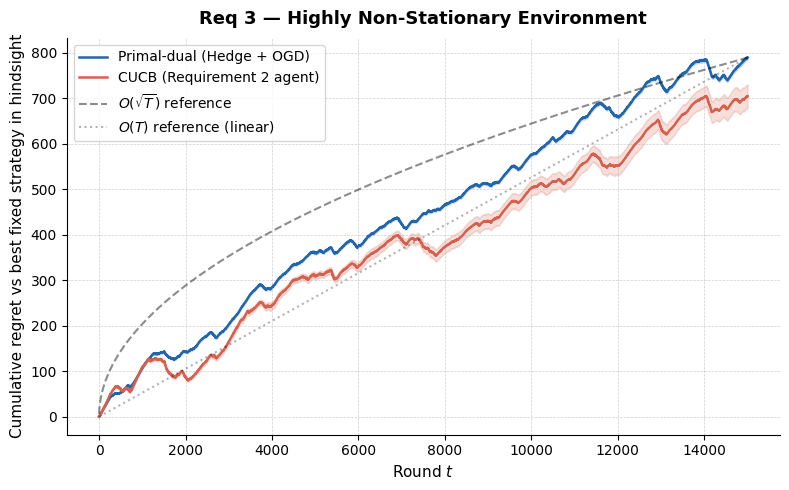

In [10]:
mean_pd_ns, std_pd_ns = summarise_regret(results_pd_ns["regret_matrix"])
mean_cucb_ns, std_cucb_ns = summarise_regret(results_cucb_ns["regret_matrix"])

fig, ax = new_figure("Req 3 — Highly Non-Stationary Environment")
plot_regret(ax, mean_pd_ns, std_pd_ns, n_trials_pd, label="Primal-dual (Hedge + OGD)")
plot_regret(ax, mean_cucb_ns, std_cucb_ns, n_trials_cucb, label="CUCB (Requirement 2 agent)")
ax.plot(ts, mean_pd_ns[-1] * np.sqrt(ts / T), 'k--', alpha=0.45, label=r'$O(\sqrt{T})$ reference')
ax.plot(ts, mean_pd_ns[-1] * (ts / T), 'k:', alpha=0.3, label=r'$O(T)$ reference (linear)')
ax.set_xlabel("Round $t$")
ax.set_ylabel("Cumulative regret vs best fixed strategy in hindsight")
ax.legend()
plt.tight_layout()
save_figure(fig, "report/figures/req3_regret_nonstationary.png")

print(f"Final regret — primal-dual : {mean_pd_ns[-1]:8.2f} +/- {std_pd_ns[-1]:.2f}")
print(f"Final regret — CUCB        : {mean_cucb_ns[-1]:8.2f} +/- {std_cucb_ns[-1]:.2f}")

Stochastic      max spend:   5560.89 / 6000   (violated: False)
Non-stationary  max spend:   4320.58 / 6000   (violated: False)
Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req3_budget_consumption.png


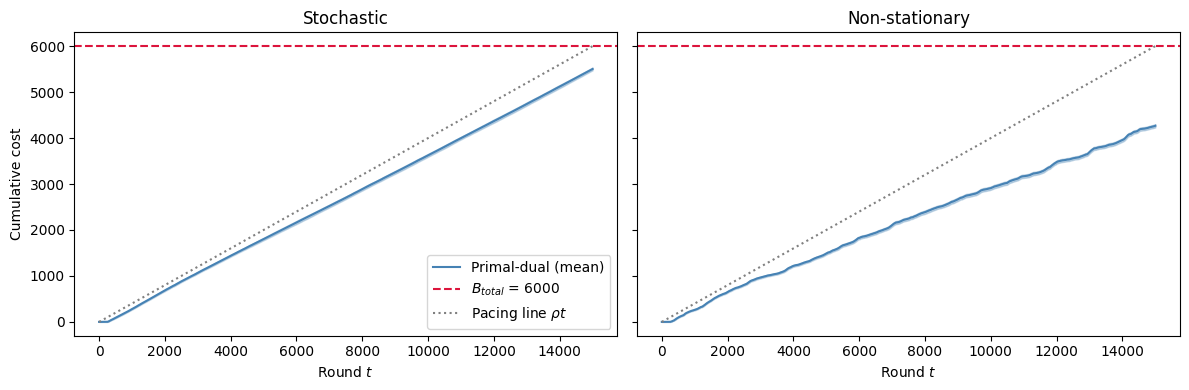

In [11]:
# Budget consumption in both environments — must never exceed B_total
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, res, title in [
    (axes[0], results_pd_stoch, "Stochastic"),
    (axes[1], results_pd_ns, "Non-stationary"),
]:
    cum = np.cumsum(res["cost_matrix"], axis=1)
    ax.plot(ts, cum.mean(axis=0), color="steelblue", label="Primal-dual (mean)")
    ax.fill_between(ts, cum.mean(axis=0) - cum.std(axis=0),
                    cum.mean(axis=0) + cum.std(axis=0), alpha=0.3, color="steelblue")
    ax.axhline(B_total, color="crimson", linestyle="--", label=f"$B_{{total}}$ = {B_total:.0f}")
    ax.plot(ts, rho * ts, color="grey", linestyle=":", label=r"Pacing line $\rho t$")
    ax.set_title(title)
    ax.set_xlabel("Round $t$")
    print(f"{title:15s} max spend: {cum[:, -1].max():9.2f} / {B_total:.0f}"
          f"   (violated: {cum[:, -1].max() > B_total + 1e-6})")
axes[0].set_ylabel("Cumulative cost")
axes[0].legend()
plt.tight_layout()
save_figure(fig, "report/figures/req3_budget_consumption.png")

## Diagnostics — the Dual Variable at Work

A single inspection trial on the non-stationary sequence: $\lambda_t$ over time and the final
Hedge distributions. $\lambda$ rises whenever spend outpaces $\rho$ and falls when the agent
underspends — this is the entire pacing mechanism, no hand-tuned pacing guards needed.

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req3_diagnostics.png
Total spend (inspection trial): 4289.8 / 6000


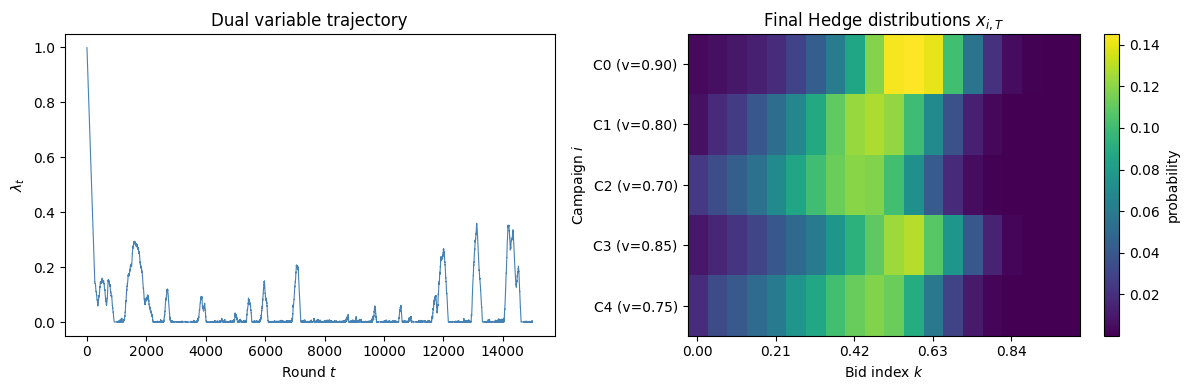

In [12]:
env_i = NonStationaryMultiCampaignEnv(values=values, T=T, sequence_seed=seq_seed)
agent_i = PrimalDualBidderAgent(bid_grid, values, B_total, T, cg,
                                rng=np.random.default_rng(0))
env_i.reset(np.random.default_rng(0))
agent_i.reset()
lmbds = np.zeros(T)
spend = np.zeros(T)
for t in range(T):
    a = agent_i.select_action()
    fb = env_i.round(a)
    agent_i.update(fb)
    lmbds[t] = agent_i.lmbd
    spend[t] = fb["cost"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(lmbds, lw=0.8, color="steelblue")
ax1.set_xlabel("Round $t$")
ax1.set_ylabel(r"$\lambda_t$")
ax1.set_title("Dual variable trajectory")

im = ax2.imshow(agent_i._x_t, aspect="auto", cmap="viridis")
ax2.set_xlabel("Bid index $k$")
ax2.set_ylabel("Campaign $i$")
ax2.set_yticks(range(N))
ax2.set_yticklabels([f"C{i} (v={values[i]:.2f})" for i in range(N)])
ax2.set_xticks(range(0, K, 4))
ax2.set_xticklabels([f"{bid_grid[k]:.2f}" for k in range(0, K, 4)])
ax2.set_title("Final Hedge distributions $x_{i,T}$")
plt.colorbar(im, ax=ax2, label="probability")
plt.tight_layout()
save_figure(fig, "report/figures/req3_diagnostics.png")
print(f"Total spend (inspection trial): {spend.sum():.1f} / {B_total:.0f}")